<a href="https://colab.research.google.com/github/Raiden900/kepfeldolgozas-beadando-2025/blob/main/Ocr_gepirat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip -q install python-doctr[torch] easyocr pytesseract opencv-python-headless matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.9/288.9 kB 16.1 MB/s eta 0:00:00


In [ ]:
import torch
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pytesseract, easyocr
from google.colab import files
from doctr.models import ocr_predictor
from doctr.io import DocumentFile
import difflib
import tempfile, os, json

print("Torch:", torch.__version__)

# EasyOCR
reader = easyocr.Reader(['en'], gpu=False)

# docTR
doctr_model = ocr_predictor(pretrained=True)

print("OK: modellek betöltve")

Torch: 2.10.0+cpu
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteDownloading https://doctr-static.mindee.com/models?id=v0.8.1/fast_base-688a8b34.pt&src=0 to /root/.cache/doctr/models/fast_base-688a8b34.pt


  0%|          | 0/65814772 [00:00<?, ?it/s]

In [ ]:
def show(img, title=None, size=(7,7)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

Saving IMG_2520.png to IMG_2520.png


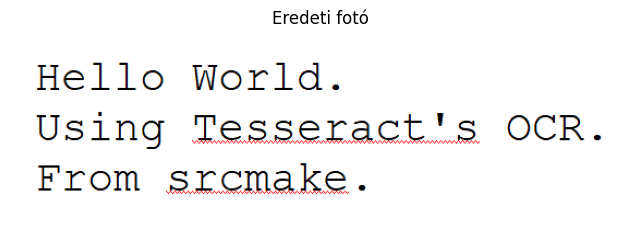

In [ ]:
uploaded = files.upload()
fname = list(uploaded.keys())[0]
img = cv.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv.IMREAD_COLOR)
show(img, "Eredeti fotó", (8,8))

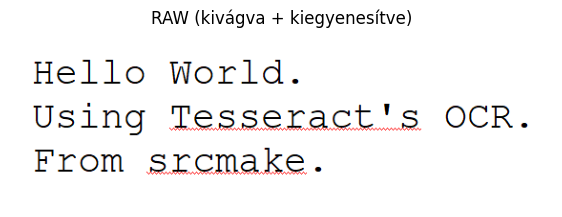

In [ ]:
def largest_quad_contour(binary):
    cnts,_ = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    best=None; area=0
    for c in cnts:
        peri=cv.arcLength(c,True)
        approx=cv.approxPolyDP(c,0.02*peri,True)
        if len(approx)==4:
            a=cv.contourArea(approx)
            if a>area: best=approx; area=a
    return best

def order_pts(pts):
    pts=pts.reshape(4,2).astype(np.float32)
    s=pts.sum(1); d=np.diff(pts, axis=1).ravel()
    tl=pts[np.argmin(s)]; br=pts[np.argmax(s)]
    tr=pts[np.argmin(d)]; bl=pts[np.argmax(d)]
    return np.array([tl,tr,br,bl], np.float32)

def warp_document(image_bgr, target_width=1200):
    ratio = target_width / image_bgr.shape[1]
    img2 = cv.resize(image_bgr, (target_width, int(image_bgr.shape[0]*ratio)))
    gray=cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
    gray=cv.GaussianBlur(gray,(5,5),0)
    edges=cv.Canny(gray,60,180)
    edges=cv.dilate(edges,np.ones((3,3),np.uint8),1)
    quad=largest_quad_contour(edges)
    if quad is None:
        return img2, False
    pts=order_pts(quad)
    w=int(max(np.linalg.norm(pts[1]-pts[0]), np.linalg.norm(pts[2]-pts[3])))
    h=int(max(np.linalg.norm(pts[3]-pts[0]), np.linalg.norm(pts[2]-pts[1])))
    M=cv.getPerspectiveTransform(pts, np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]], np.float32))
    warped=cv.warpPerspective(img2, M, (w,h))
    return warped, True

raw, ok = warp_document(img)
if not ok:
    raw = img

show(raw, "RAW (kivágva + kiegyenesítve)")

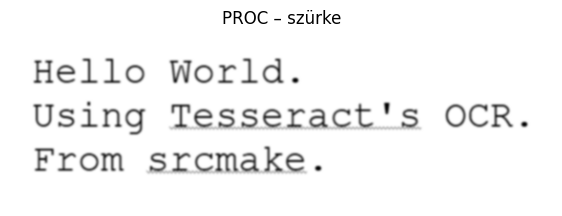

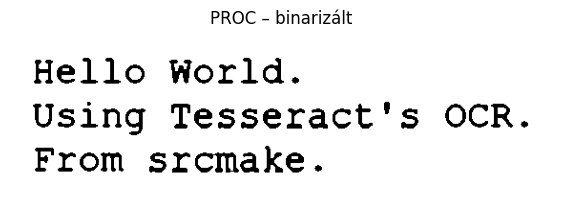

In [ ]:
def enhance_for_ocr(bgr):
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    gray = cv.GaussianBlur(gray, (5,5), 0)
    _, binimg = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    binimg = cv.morphologyEx(binimg, cv.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)
    return gray, binimg

gray, binimg = enhance_for_ocr(raw)

show(gray, "PROC – szürke")
show(binimg, "PROC – binarizált")

In [ ]:
# EasyOCR

def ocr_easy(img_gray):
    res = reader.readtext(
        img_gray,
        detail=0,
        paragraph=True,
        decoder='beamsearch',     # pontosabb, de kicsit lassabb
        text_threshold=0.4,       # jobban felismeri a halvány betűket
        low_text=0.3
    )
    return "\n".join(res)

# Tesseract
def ocr_tess(img_gray):
    cfg = "--oem 1 --psm 4 -l eng"
    return pytesseract.image_to_string(img_gray, config=cfg)

# docTR
def ocr_doctr(image_bgr):
    tmp_path = os.path.join(tempfile.gettempdir(), "doctr_tmp.jpg")
    cv.imwrite(tmp_path, image_bgr)
    doc = DocumentFile.from_images(tmp_path)
    result = doctr_model(doc)

    text_lines = []
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                words = [word.value for word in line.words]
                text_lines.append(" ".join(words))
    return "\n".join(text_lines).strip()


txt_easy_raw  = ocr_easy(cv.cvtColor(raw, cv.COLOR_BGR2GRAY))
txt_easy_proc = ocr_easy(binimg)

txt_tess_raw  = ocr_tess(cv.cvtColor(raw, cv.COLOR_BGR2GRAY))
txt_tess_proc = ocr_tess(binimg)

txt_doctr_raw  = ocr_doctr(raw)
txt_doctr_proc = ocr_doctr(cv.cvtColor(binimg, cv.COLOR_GRAY2BGR))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
import difflib

expected = "Hello World. Using Tesseract's OCR. From srcmake."

def normalize(text):
    text = text.replace("\x0c", "")   # kontroll karakter törlés
    text = text.replace("\n", " ")    # sortörés -> space
    text = " ".join(text.split())     # több space -> egy
    return text.upper().strip()


norm_easy_raw  = normalize(txt_easy_raw)
norm_easy_proc = normalize(txt_easy_proc)

norm_tess_raw  = normalize(txt_tess_raw)
norm_tess_proc = normalize(txt_tess_proc)

norm_doctr_raw  = normalize(txt_doctr_raw)
norm_doctr_proc = normalize(txt_doctr_proc)

norm_expected = normalize(expected)


print("\n" + "="*70)
print("OCR EREDMÉNYEK")
print("="*70)

print("\nELVÁRT:")
print(norm_expected)

print("\nEasyOCR RAW:")
print(norm_easy_raw)

print("\nEasyOCR PROC:")
print(norm_easy_proc)

print("\nTesseract RAW:")
print(norm_tess_raw)

print("\nTesseract PROC:")
print(norm_tess_proc)

print("\ndocTR RAW:")
print(norm_doctr_raw)

print("\ndocTR PROC:")
print(norm_doctr_proc)

print("\n" + "="*70)


OCR EREDMÉNYEK

ELVÁRT:
HELLO WORLD. USING TESSERACT'S OCR. FROM SRCMAKE.

EasyOCR RAW:
HELLO WORLD. USING TESSERACT' S OCR _ FROM SRCMAKE _

EasyOCR PROC:
HELLO WORLD. USING TESSERACT ' $ OCR . FROM SRCMAKE _

Tesseract RAW:
HELLO WORLD. USING TESSERACT'S OCR. FROM SRCEMAKE.

Tesseract PROC:
HELLO WORLD. USING TESSERACT'S OCR. FROM SRCEMAKE.

docTR RAW:
HELLO NORLD. USING LESSERACT S - OCR. FROM SRCMAKE. -

docTR PROC:
HELLO NORLD. USING TESSERACT'S OCR. FROM SRCMAKE.



In [ ]:
def similarity(a, b):
    return difflib.SequenceMatcher(None, a, b).ratio()

results = {
    "EasyOCR RAW": similarity(norm_expected, norm_easy_raw),
    "EasyOCR PROC": similarity(norm_expected, norm_easy_proc),
    "Tesseract RAW": similarity(norm_expected, norm_tess_raw),
    "Tesseract PROC": similarity(norm_expected, norm_tess_proc),
    "docTR RAW": similarity(norm_expected, norm_doctr_raw),
    "docTR PROC": similarity(norm_expected, norm_doctr_proc),
}

print("\n" + "="*70)
print("PONTOSSÁGI EREDMÉNYEK")
print("="*70)

for name, val in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:20s} -> {val*100:6.2f}%")

print("="*70)



print("\n" + "="*60)
print("MODELL SZERINTI EREDMÉNYEK")
print("="*60)

print("\nEasyOCR")
print(f"  RAW  -> {similarity(norm_expected, norm_easy_raw)*100:.2f}%")
print(f"  PROC -> {similarity(norm_expected, norm_easy_proc)*100:.2f}%")

print("\nTesseract")
print(f"  RAW  -> {similarity(norm_expected, norm_tess_raw)*100:.2f}%")
print(f"  PROC -> {similarity(norm_expected, norm_tess_proc)*100:.2f}%")

print("\ndocTR")
print(f"  RAW  -> {similarity(norm_expected, norm_doctr_raw)*100:.2f}%")
print(f"  PROC -> {similarity(norm_expected, norm_doctr_proc)*100:.2f}%")


PONTOSSÁGI EREDMÉNYEK
Tesseract RAW        ->  98.99%
Tesseract PROC       ->  98.99%
docTR PROC           ->  97.96%
EasyOCR RAW          ->  93.07%
EasyOCR PROC         ->  92.16%
docTR RAW            ->  90.20%

MODELL SZERINTI EREDMÉNYEK

EasyOCR
  RAW  -> 93.07%
  PROC -> 92.16%

Tesseract
  RAW  -> 98.99%
  PROC -> 98.99%

docTR
  RAW  -> 90.20%
  PROC -> 97.96%


In [ ]:
os.makedirs("/content/outputs", exist_ok=True)

with open("/content/outputs/all_ocr_results.json","w",encoding="utf-8") as f:
    json.dump({
        "expected": expected,
        "easy_raw": txt_easy_raw,
        "easy_proc": txt_easy_proc,
        "tess_raw": txt_tess_raw,
        "tess_proc": txt_tess_proc,
        "doctr_raw": txt_doctr_raw,
        "doctr_proc": txt_doctr_proc,
        "accuracy": results
    }, f, indent=2)

print("Mentve: /content/outputs/all_ocr_results.json")

Mentve: /content/outputs/all_ocr_results.json
